In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('Mall_Customers.csv')


In [2]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [3]:
# Quick Look
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


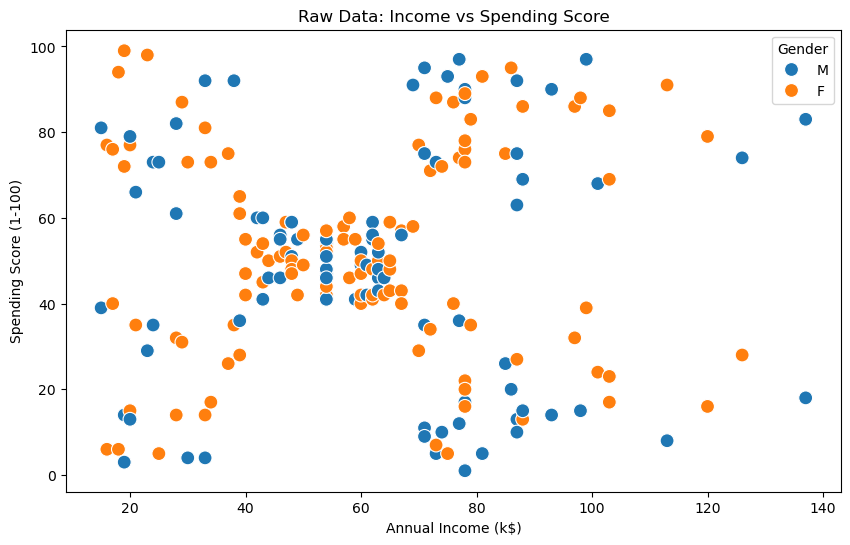

In [4]:
# Visualizing the distribution of Spending Score vs Income
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', s=100)
plt.title('Raw Data: Income vs Spending Score')
plt.show()

**Insight:** Even before clustering, we can see "blobs" of data points. There seems to be a group with high income but low spending, and another with low income but high spending. This is a prime candidate for K-Means.

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

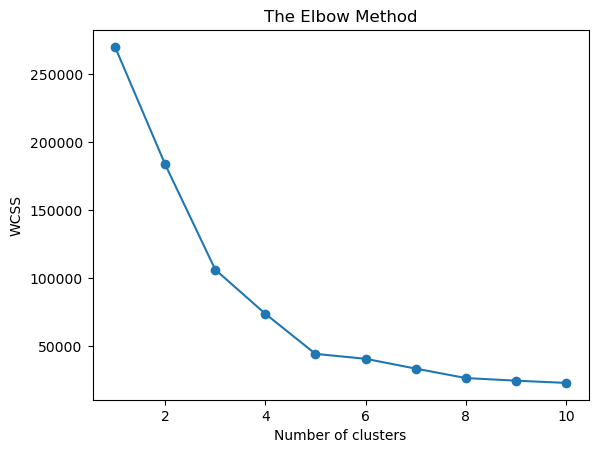

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

**Insight:** The elbow appears clearly at $k=5$. Beyond 5 clusters, the drop in WCSS (Within-Cluster Sum of Squares) slows down significantly.

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


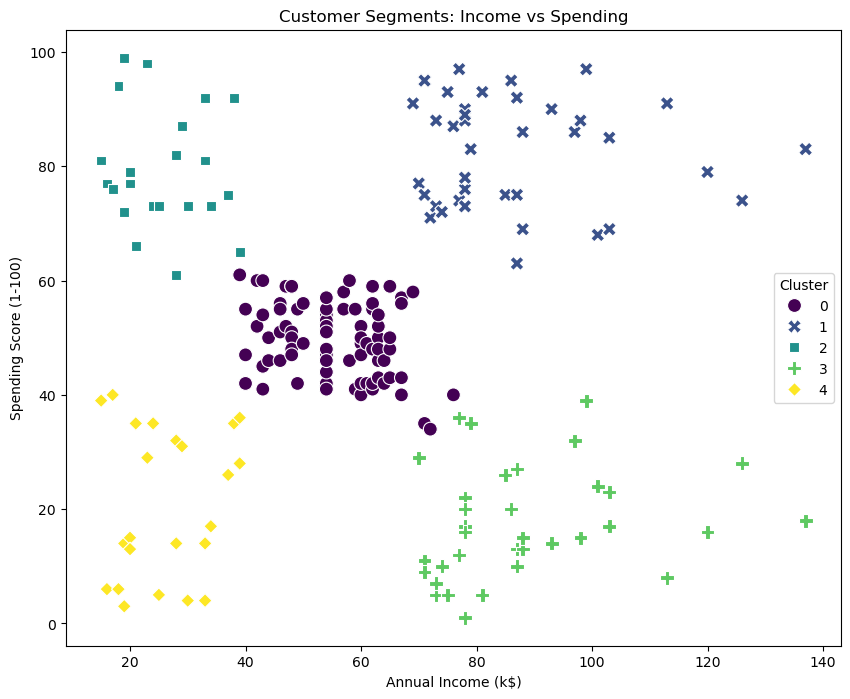

In [6]:
# Training the model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=100, style='Cluster')
plt.title('Customer Segments: Income vs Spending')
plt.show()

## Cluster Analysis & Actionable Marketing Strategies
After applying the K-Means algorithm, we identified 5 distinct customer segments. Below is the strategic breakdown for the marketing department:

#### 1. The "Target Elite" (High Income, High Spending)
**Profile:** Customers who have high purchasing power and frequently buy premium products.

**Strategy:** Implement a VIP Loyalty Program.

**Action:** Send invitations for exclusive "First Look" events, offer personal shopping assistants, and provide early access to new collections.

#### 2. The "Frugal High-Earners" (High Income, Low Spending)
**Profile:** Wealthy individuals who are cautious with their spending.

**Strategy:** Focus on Value and Quality.

**Action:** Avoid "Flash Sale" tactics. Instead, use content marketing to highlight product durability, craftsmanship, and long-term investment value.

#### 3. The "Steady Spenders" (Average Income, Average Spending)
**Profile:** The middle-class backbone of the mall; they are consistent but careful.

**Strategy:** Retention & Engagement.

**Action:** Use "Points-based" loyalty rewards to encourage repeat visits. Monthly newsletters with "Top Picks" in their favorite categories work best here.

#### 4. The "Spenders on a Budget" (Low Income, High Spending)
**Profile:** Often younger or trend-driven customers who spend a high proportion of their income.

**Strategy:** High-Volume / Trend Alerts.

**Action:** Use SMS and App notifications for "Limited Time Offers" and "Influencer Collections." Focus on FOMO (Fear Of Missing Out) marketing.

#### 5. The "Budget Conscious" (Low Income, Low Spending)
**Profile:** Practical shoppers who likely only visit for essentials or extreme discounts.

**Strategy:** Price-Sensitivity Campaigns.

**Action:** Target with clearance sale alerts, "Buy One Get One" (BOGO) offers, and discount coupons to drive foot traffic.